In [20]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_pure_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
N_SEGS = 6
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, qS, phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")

# S schedule: jump to next S after stuck_iters of no improvement
S_schedule  = [3.0, 10.0, 30.0]
stuck_iters = 10000

# annealing dict
anneal_state = {
    'S':              S_schedule[0],
    'stage':          0,         # index into S_schedule
    'ref_max_ld':     None,      # max_ld at last check
    'ref_iter':       0,
    'stuck_count':    0,
}



def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cos_qS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))

            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))#*anneal_state['S']
        except Exception:
            pass
    return out



def prior_transform(u):
    logm1lim = [5.82507, 5.82762]
    logm2lim = [1.99252, 1.99310]
    alim = [0.49334, 0.50078]
    p0lim = [15.70599, 15.75367]
    e0lim = [0.74388, 0.74418]
    qSlim = [0.79926, 0.86149]
    phiSlim = [3.48384, 3.66905]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (qSlim[1] - qSlim[0]) * u[:, 5] + qSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.82507, 5.82762]
    logm2lim = [1.99252, 1.99310]
    alim = [0.49334, 0.50078]
    p0lim = [15.70599, 15.75367]
    e0lim = [0.74388, 0.74418]
    qSlim = [0.79926, 0.86149]
    phiSlim = [3.48384, 3.66905]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - qSlim[0]) / (qSlim[1] - qSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

DEBUG:few:Configuration file not found in '/nfs/home/svu/e1498138/emri_search/work/few.ini'
DEBUG:few:Configuration file not found in '/home/svu/e1498138/.config/few.ini'
DEBUG:few:Configuration file not found in '/etc/xdg/few/v0.0/few.ini'
DEBUG:few:ConfigInitialization: final configuration entries are
DEBUG:few: ignore_cfg=False (from: ConfigSource.DEFAULT)
DEBUG:few: ignore_env=False (from: ConfigSource.DEFAULT)
DEBUG:few: config_file=None (from: ConfigSource.DEFAULT)
DEBUG:few: log_level=20 (from: ConfigSource.SETTER)
DEBUG:few: log_format=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_registry_path=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_storage_path=/nfs/home/svu/e1498138/FastEMRIWaveforms/src/few/data (from: ConfigSource.DEFAULT)
DEBUG:few: file_download_path=/nfs/home/svu/e1498138/FastEMRIWaveforms/src/few/data (from: ConfigSource.DEFAULT)
DEBUG:few: file_allow_download=True (from: ConfigSource.DEFAULT)
DEBUG:few: file_integrity_check=once (from: ConfigSource.DEFAU

Using dt=5s, T=1.0yr, TDI gen=1, N_segs=6
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Setting up log_density and prior functions...


In [21]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage2_merge/'


In [22]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [23]:
len(sampler.now_covariances)

1

In [24]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.82632391,  1.99270085,  0.49707313, 15.7304718 ,  0.74414133,
         0.79930032,  3.49534624]])

In [25]:
log_density(maxld_pt1)

array([96.95956675])

In [26]:
log_density([param_true])

array([78.15362705])

In [39]:
param_ranges = [(5.82507, 5.82762), (1.99252, 1.99310), (0.49334, 0.50078), (15.70599, 15.75367), (0.74388, 0.74418), (0.79926, 0.86149), (3.48384, 3.66905)
                ]
param_ranges

[(5.82507, 5.82762),
 (1.99252, 1.9931),
 (0.49334, 0.50078),
 (15.70599, 15.75367),
 (0.74388, 0.74418),
 (0.79926, 0.86149),
 (3.48384, 3.66905)]

In [40]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

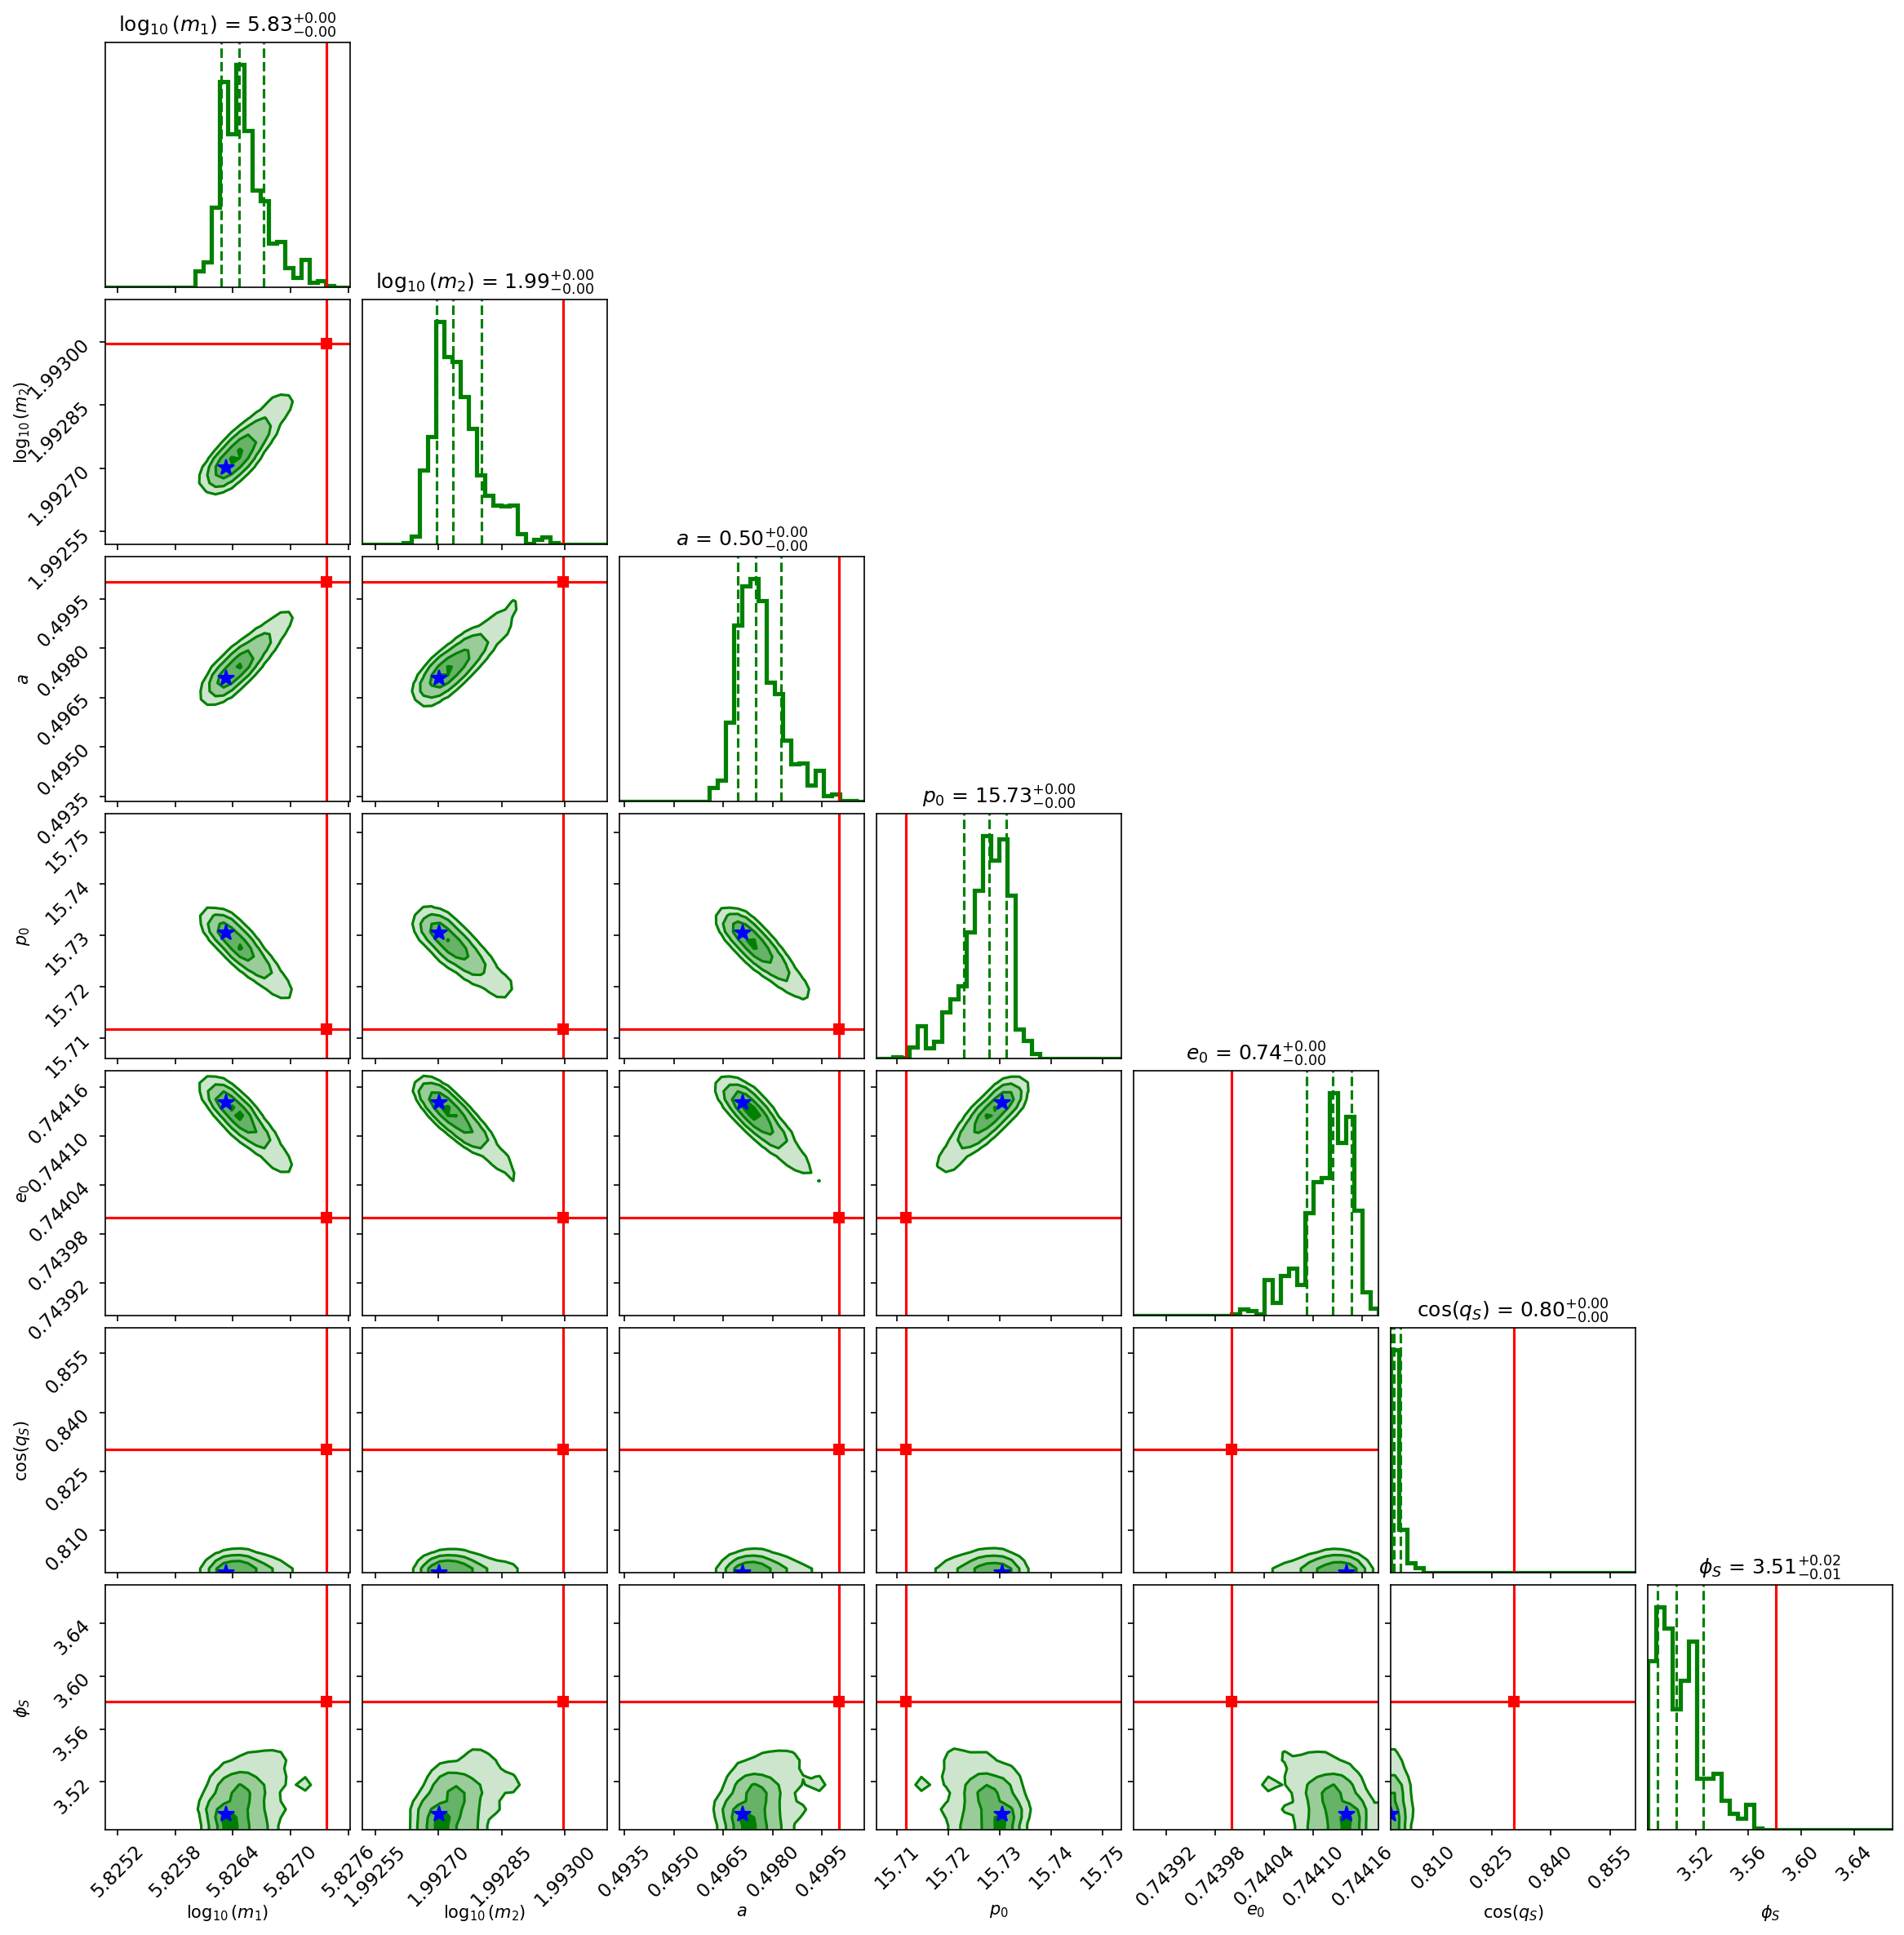

In [41]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

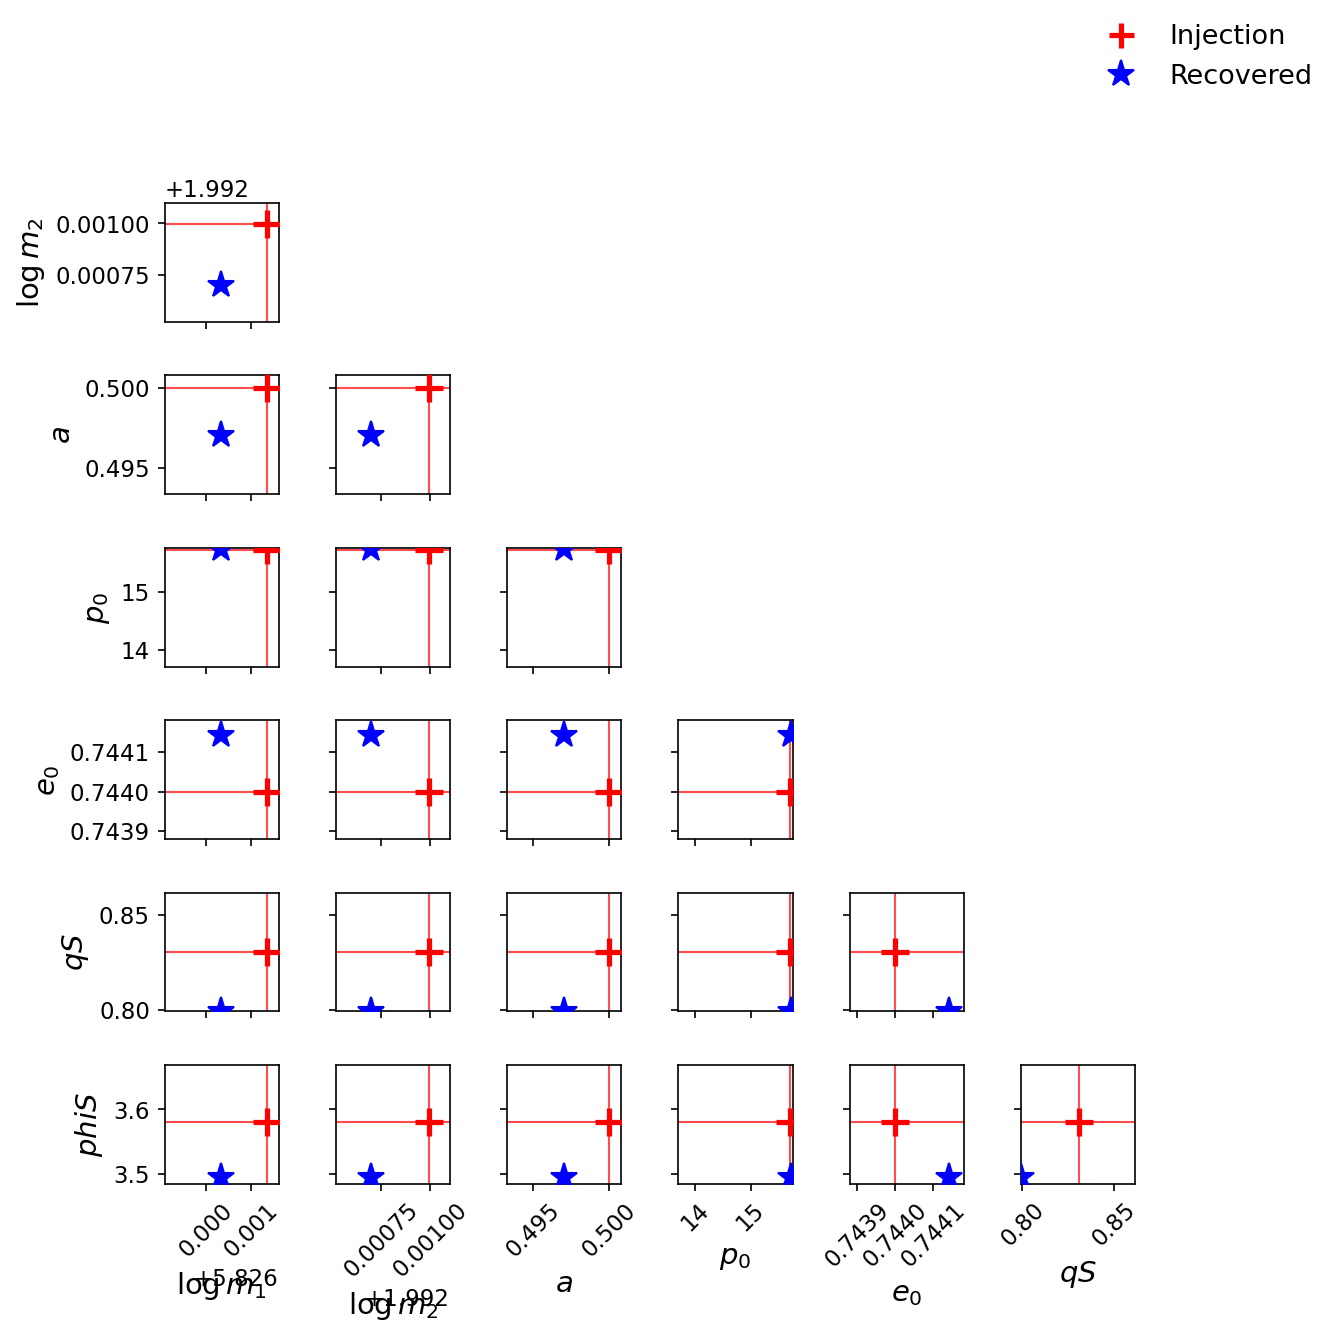

In [30]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [31]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82632391,  1.99270085,  0.49707313, 15.7304718 ,  0.74414133,
         0.79930032,  3.49534624]])

In [32]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [33]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [34]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [35]:
logden_theory_proc1

array([ 96.95956675,  97.09587263,  97.27819544,  97.43609427,
        97.60738854,  97.7482426 ,  97.85863319,  97.94341466,
        98.03038521,  98.10491022,  98.22023126,  98.37693526,
        98.55489181,  98.70892157,  98.82686173,  98.92939408,
        99.0434816 ,  99.12636719,  99.20113405,  99.30484536,
        99.40644537,  99.48574568,  99.54459391,  99.60620616,
        99.64784543,  99.71068582,  99.78818949,  99.84776487,
        99.90101752,  99.94439628, 100.00010165, 100.04433053,
       100.05776883, 100.1188091 , 100.14233941, 100.13860486,
       100.19987049, 100.27225352, 100.29177656, 100.29423036,
       100.37259262, 100.39103842, 100.34499966, 100.33973382,
       100.32511332, 100.36260555, 100.45687884, 100.51322819,
       100.53642044, 100.56384243])

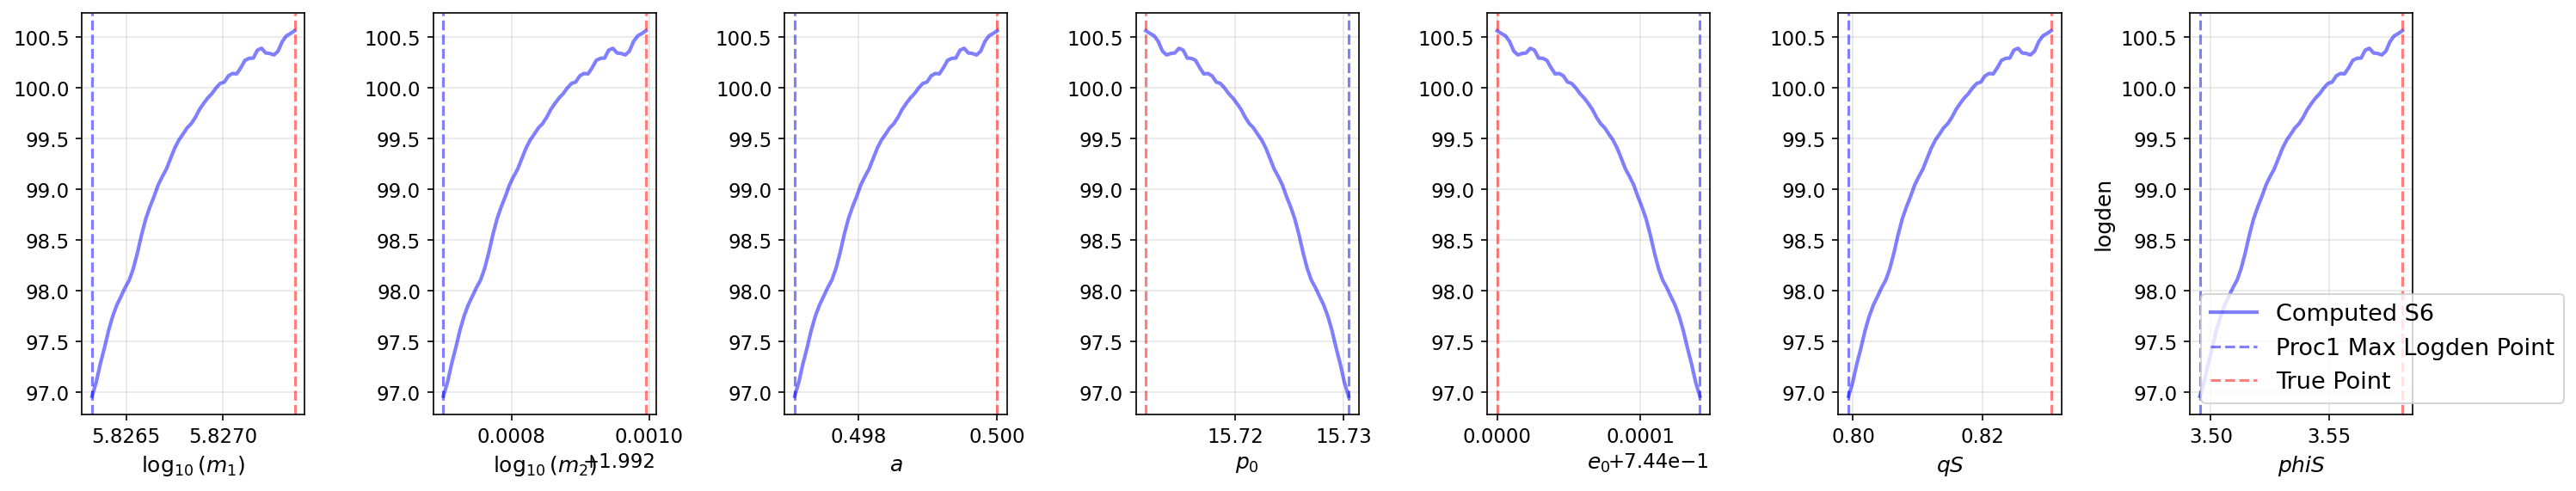

In [42]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S6')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [37]:
# Bootstrap-resample the weighted posterior (same as paris3_lhs_s6_ext.py)
weights_norm = weights / weights.sum()
rng_rs = np.random.default_rng(0)
idx_rs = rng_rs.choice(len(samples), size=50_000, replace=True, p=weights_norm)
cov_posterior = np.cov(samples[idx_rs].T)
sigma_diag = np.sqrt(np.diag(cov_posterior))

mu_center = maxld_pt1.ravel()          # max-log-density point (== mu_center in the script)
param_true_arr = np.asarray(param_true).ravel()

n_sigma_needed = (param_true_arr - mu_center) / sigma_diag

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, mu, sig, ns in zip(param_names, mu_center, sigma_diag, n_sigma_needed):
    print(f'{name:8s}: mu={mu:.5f}  sigma={sig:.5f}  true offset = {ns:+.2f} sigma')

print(f'\nMax |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): '
      f'{np.max(np.abs(n_sigma_needed)):.2f}')

logm1   : mu=5.82632  sigma=0.00024  true offset = +4.36 sigma
logm2   : mu=1.99270  sigma=0.00006  true offset = +4.94 sigma
a       : mu=0.49707  sigma=0.00069  true offset = +4.23 sigma
p0      : mu=15.73047  sigma=0.00444  true offset = -4.23 sigma
e0      : mu=0.74414  sigma=0.00003  true offset = -4.80 sigma
cos_qS  : mu=0.79930  sigma=0.00141  true offset = +22.19 sigma
phiS    : mu=3.49535  sigma=0.01797  true offset = +4.76 sigma

Max |N_sigma| across dims (box would need N_SIGMA >= this to contain truth): 22.19


In [38]:
# Prior bounds (same as paris3_lhs_s6_ext.py / stage1_anneal_s12 prior)
p1_lo = np.array([5.6, 1.7, 0.3, 13.5, 0.6, -1.0, 0.0])
p1_hi = np.array([6.4, 2.3, 0.99, 16.5, 0.9, 1.0, 2 * np.pi])

# N_SIGMA needed to cover the true point (from previous cell), rounded up
N_SIGMA = 30
print(f'N_SIGMA = {N_SIGMA:.0f}')

ellipse_lo = np.clip(mu_center - N_SIGMA * sigma_diag, p1_lo, p1_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA * sigma_diag, p1_lo, p1_hi)
box_width  = ellipse_hi - ellipse_lo
full_width = p1_hi - p1_lo

param_names = ['logm1', 'logm2', 'a', 'p0', 'e0', 'cos_qS', 'phiS']
for name, lo, hi, w, fw in zip(param_names, ellipse_lo, ellipse_hi, box_width, full_width):
    print(f'{name:8s}: [{lo:.5f}, {hi:.5f}]  width={w:.5f}  '
          f'({100*w/fw:.2f}% of full prior width)')

vol_frac = np.prod(box_width / full_width)
print(f'\nBox volume fraction of full prior box: {vol_frac:.3e}  (log10 = {np.log10(vol_frac):.2f})')


N_SIGMA = 30
logm1   : [5.81912, 5.83352]  width=0.01440  (1.80% of full prior width)
logm2   : [1.99091, 1.99449]  width=0.00357  (0.60% of full prior width)
a       : [0.47630, 0.51785]  width=0.04155  (6.02% of full prior width)
p0      : [15.59730, 15.86365]  width=0.26635  (8.88% of full prior width)
e0      : [0.74326, 0.74502]  width=0.00177  (0.59% of full prior width)
cos_qS  : [0.75698, 0.84162]  width=0.08463  (4.23% of full prior width)
phiS    : [2.95638, 4.03431]  width=1.07794  (17.16% of full prior width)

Box volume fraction of full prior box: 2.449e-11  (log10 = -10.61)
